In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn import metrics
import matplotlib.pyplot as plt
from math import sqrt

In [2]:
df = pd.read_csv("C:/Users/PC/Desktop/state_weather_aqi_data_mf2.csv")

In [3]:
def rmsle(real, predicted):
    sum_error = 0.0
    for x in range(len(predicted)):
        if predicted[x] < 0 or real[x] < 0:
            continue
        p = np.log(predicted[x] + 1)
        r = np.log(real[x] + 1)
        sum_error += (p - r) ** 2
    return np.sqrt(sum_error / len(predicted))

In [4]:
# Tiền xử lý dữ liệu
x1 = df.iloc[:, :12].values
y1 = df.iloc[:, 12:13].values

ohe = OneHotEncoder()
x_new1 = pd.DataFrame(ohe.fit_transform(x1[:, [0]]).toarray())  # State
x_new2 = pd.DataFrame(ohe.fit_transform(x1[:, [1]]).toarray())  # City
x_new3 = pd.DataFrame(ohe.fit_transform(x1[:, [2]]).toarray())  # Station

feature_set = pd.concat([x_new1, x_new2, x_new3, pd.DataFrame(x1[:, 5:12])], axis=1, sort=False)

In [5]:
# Danh sách lưu kết quả
r2_list, rmse_list, mae_list, mse_list, rmsle_list = [], [], [], [], []

In [6]:
# Train 20 lần
for i in range(20):
    x_train, x_test, y_train, y_test = train_test_split(feature_set, y1, test_size=0.25, random_state=i)
    
    model = DecisionTreeRegressor(random_state=0)
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    # Tính các metric
    r2 = metrics.r2_score(y_test, y_pred)
    rmse = sqrt(metrics.mean_squared_error(y_test, y_pred))
    mae = metrics.mean_absolute_error(y_test, y_pred)
    mse = metrics.mean_squared_error(y_test, y_pred)
    rmsle_val = rmsle(y_test, y_pred)

    # Lưu kết quả vào list
    r2_list.append(r2)
    rmse_list.append(rmse)
    mae_list.append(mae)
    mse_list.append(mse)
    rmsle_list.append(rmsle_val)

In [7]:
# Tạo DataFrame lưu tất cả kết quả
results_df = pd.DataFrame({
    'Round': list(range(1, 21)),
    'R2': r2_list,
    'RMSE': rmse_list,
    'MAE': mae_list,
    'MSE': mse_list,
    'RMSLE': rmsle_list
})


In [8]:
# Xuất file Excel
results_df.to_excel('results_metrics.xlsx', index=False)

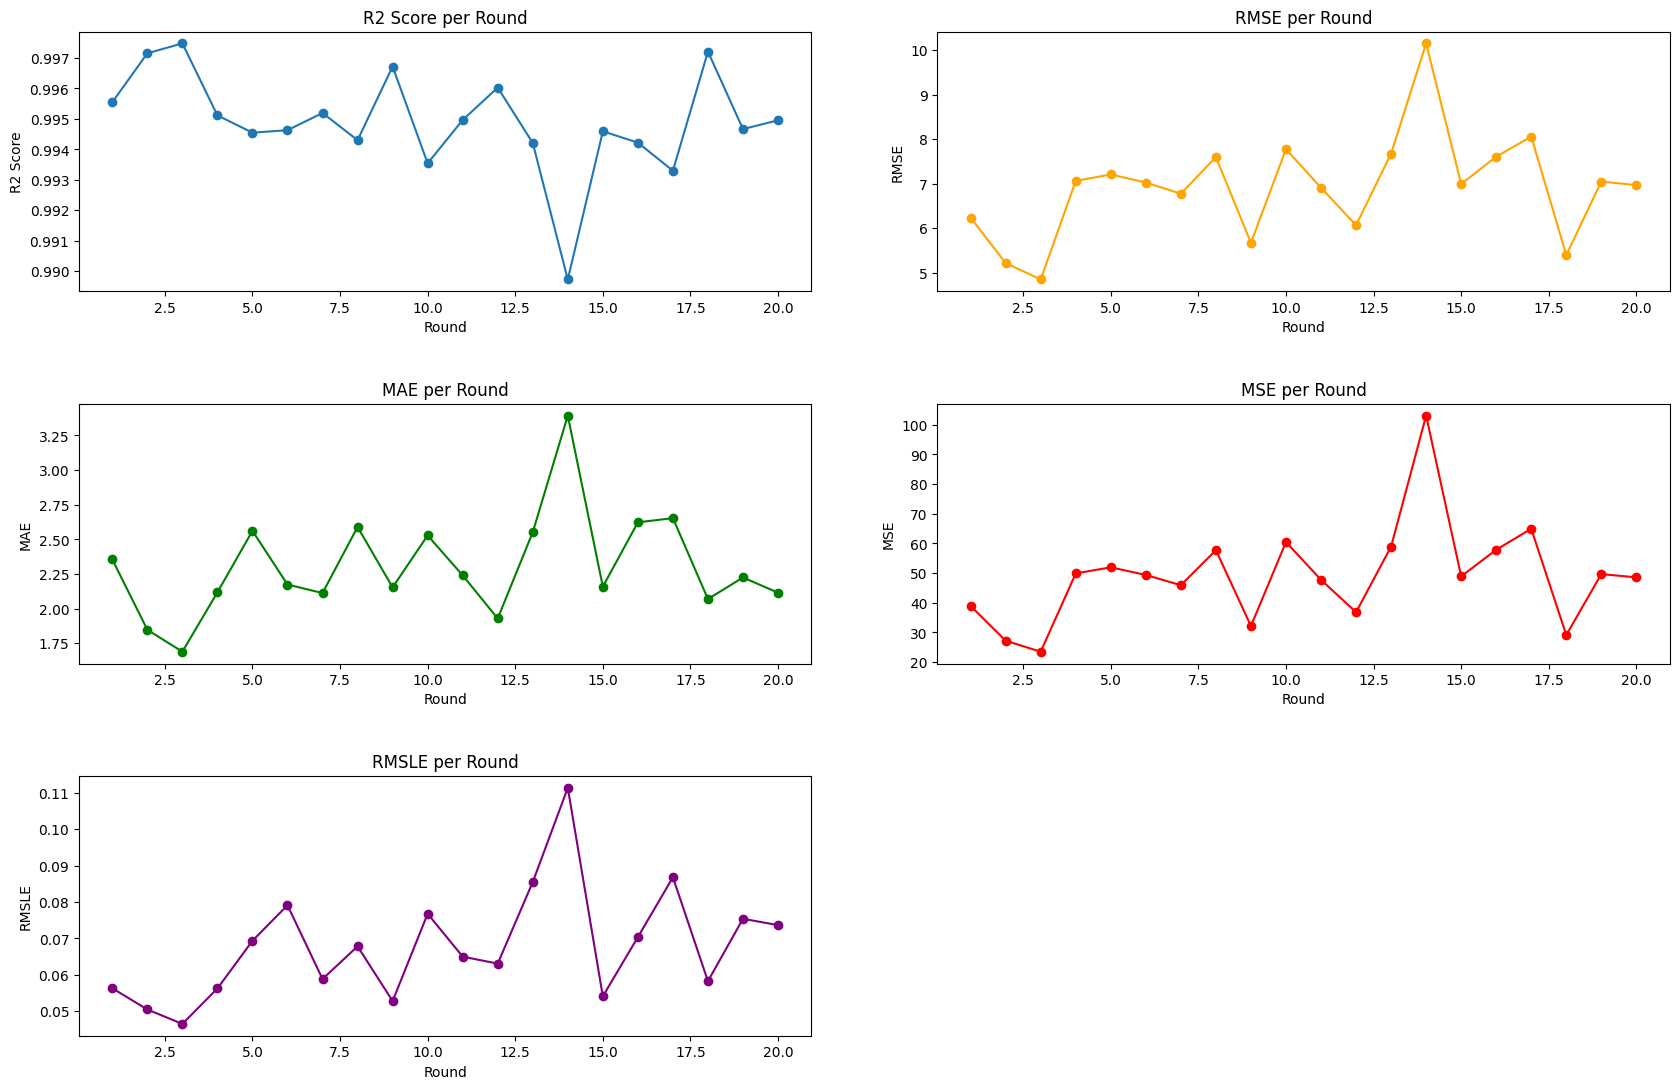

In [9]:
# Vẽ biểu đồ
fig, axs = plt.subplots(3, 2, figsize=(18, 12))
fig.tight_layout(pad=6)

# R2
axs[0, 0].plot(results_df['Round'], results_df['R2'], marker='o')
axs[0, 0].set_title('R2 Score per Round')
axs[0, 0].set_xlabel('Round')
axs[0, 0].set_ylabel('R2 Score')

# RMSE
axs[0, 1].plot(results_df['Round'], results_df['RMSE'], marker='o', color='orange')
axs[0, 1].set_title('RMSE per Round')
axs[0, 1].set_xlabel('Round')
axs[0, 1].set_ylabel('RMSE')

# MAE
axs[1, 0].plot(results_df['Round'], results_df['MAE'], marker='o', color='green')
axs[1, 0].set_title('MAE per Round')
axs[1, 0].set_xlabel('Round')
axs[1, 0].set_ylabel('MAE')

# MSE
axs[1, 1].plot(results_df['Round'], results_df['MSE'], marker='o', color='red')
axs[1, 1].set_title('MSE per Round')
axs[1, 1].set_xlabel('Round')
axs[1, 1].set_ylabel('MSE')

# RMSLE
axs[2, 0].plot(results_df['Round'], results_df['RMSLE'], marker='o', color='purple')
axs[2, 0].set_title('RMSLE per Round')
axs[2, 0].set_xlabel('Round')
axs[2, 0].set_ylabel('RMSLE')

# Xóa ô trống dư thừa (vì 3x2 = 6, nhưng ta chỉ cần 5 biểu đồ)
fig.delaxes(axs[2, 1])

# Lưu ảnh
plt.savefig('metrics_per_round.png', dpi=300)
plt.show()

In [14]:
# Dự đoán bằng model cây quyết định (Decision Tree)
dt_y_predict = model.predict(x_test)  # Sửa lỗi: thay 'dt_model' bằng 'model'

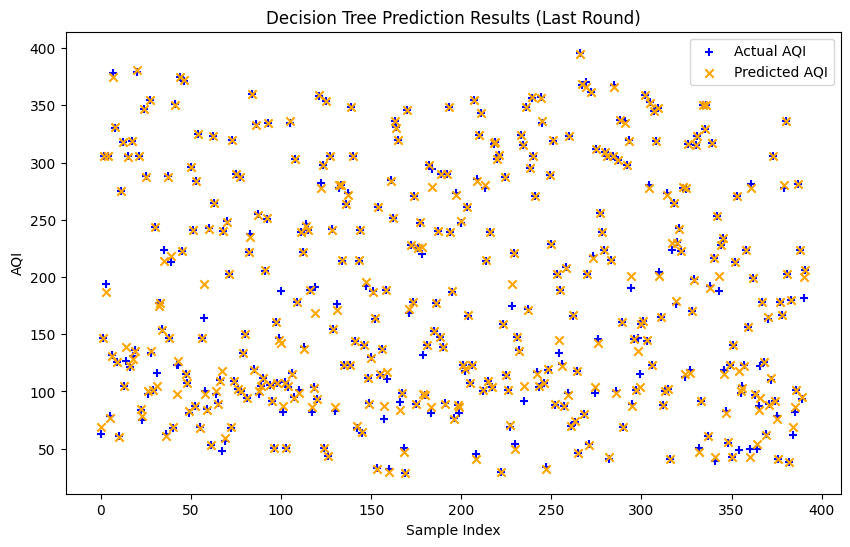

In [16]:
# Vẽ biểu đồ Actual vs Predicted AQI
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test)), y_test, c='blue', marker='+', label='Actual AQI')
plt.scatter(range(len(dt_y_predict)), dt_y_predict, c='orange', marker='x', label='Predicted AQI')
plt.xlabel('Sample Index')
plt.ylabel('AQI')
plt.title('Decision Tree Prediction Results (Last Round)')
plt.legend()
plt.show()